# General Admission visits to 311 Abbot

**HOW TO USE THIS JUPYTER NOTEBOOK:** highlight the cell by clicking on it. You should see a green or blue box surround it. Then hold the Shift key and press Enter. You should see the highlight box move on to the next cell, and it will print or plot whatever the code says to do.
Try it here. Click on the gray text box below to highlight the cell, then hold Shift and press Enter.

In [1]:
print("Hello world!")

Hello world!


If it says **Hello world!** to you below the gray cell, it worked!

## Import statements, classes, and methods. 
Run these (Shift, Enter) then keep going. They shouldn't spit anything out at you. If they do, tell Abbie.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import ipywidgets as widgets
import traitlets
import datetime
from IPython.display import display
from tkinter import Tk, filedialog

In [7]:
xlsx_file = "./311.xlsx"
df = pd.read_excel(xlsx_file, engine='openpyxl')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838 entries, 0 to 837
Data columns (total 5 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   Sales Order Item\Date added                                 838 non-null    datetime64[ns]
 1   Sales Order Item\Sales Order Item Ticket\Tickets\Scan date  11 non-null     object        
 2   Sales Order Item\Quantity                                   838 non-null    int64         
 3   Constituent\MSU Affiliation Attribute\Value                 825 non-null    object        
 4   QUERYRECID                                                  838 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 32.9+ KB
None


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [8]:
df = df.rename(columns={'Sales Order Item\\Date added': 'DateTime', 
                        'Sales Order Item\\Quantity': 'Quantity', 
                        'Constituent\\MSU Affiliation Attribute\\Value': 'Affiliation'})
df['Day'] = [j.strftime('%a') for j in df['DateTime']]
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838 entries, 0 to 837
Data columns (total 6 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   DateTime                                                    838 non-null    datetime64[ns]
 1   Sales Order Item\Sales Order Item Ticket\Tickets\Scan date  11 non-null     object        
 2   Quantity                                                    838 non-null    int64         
 3   Affiliation                                                 825 non-null    object        
 4   QUERYRECID                                                  838 non-null    object        
 5   Day                                                         838 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 39.4+ KB
None


In [9]:
df['Time'] = [j.strftime('%-H:%M') for j in df['DateTime']]
df['Date'] = [j.strftime('%Y-%m-%d') for j in df['DateTime']]
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838 entries, 0 to 837
Data columns (total 8 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   DateTime                                                    838 non-null    datetime64[ns]
 1   Sales Order Item\Sales Order Item Ticket\Tickets\Scan date  11 non-null     object        
 2   Quantity                                                    838 non-null    int64         
 3   Affiliation                                                 825 non-null    object        
 4   QUERYRECID                                                  838 non-null    object        
 5   Day                                                         838 non-null    object        
 6   Time                                                        838 non-null    object        
 7   Date                       

In [10]:
def which_exhibition(visit_date):
    if visit_date <= "2024-12-24":
        return "Monumentum"
    elif visit_date >= "2025-02-01" and visit_date <= "2025-07-28":
        return "Techno"
    elif visit_date >= "2025-09-04":
        return "Physical Spells"
    else:
        return "No Exhib"

In [11]:
df['Exhibition'] = [which_exhibition(j) for j in df['Date']]

In [12]:
display(df)

,DateTime,Sales Order Item\Sales Order Item Ticket\Tickets\Scan date,Quantity,Affiliation,QUERYRECID,Day,Time,Date,Exhibition
0,2024-10-07 16:13:52.883,NaN,1,Faculty/Staff,01eaec6d-a11e-48c9-a50d-71717a71b39e,Mon,16:13,2024-10-07,Monumentum
1,2024-10-08 15:11:26.540,10/8/2024 3:12:20 PM -04:00,1,NaN,c06820d7-5bf1-4bfe-b051-48c003fa7197,Tue,15:11,2024-10-08,Monumentum
2,2024-10-08 15:18:43.887,10/8/2024 3:19:04 PM -04:00,1,NaN,c7dae1a1-3ce0-4aa1-b32a-899b80452a24,Tue,15:18,2024-10-08,Monumentum
3,2024-10-09 10:48:52.053,NaN,1,Not MSU,a359dca3-be49-4255-bc7c-692a33447643,Wed,10:48,2024-10-09,Monumentum
4,2024-10-15 13:54:02.083,NaN,2,Alum,88a539dc-154a-4611-947b-cdc7b6cc73c0,Tue,13:54,2024-10-15,Monumentum
...,...,...,...,...,...,...,...,...,...
833,2025-08-19 11:57:04.327,NaN,2,Student,eeed016e-bc51-44ae-b196-6bd01cddc76a,Tue,11:57,2025-08-19,No Exhib
834,2025-09-04 12:56:23.427,NaN,1,Faculty/Staff,84105291-a0d0-4794-8d92-cf0030cf4b7f,Thu,12:56,2025-09-04,Physical Spells
835,2025-09-05 14:42:17.110,NaN,1,Not MSU,b7e18d2a-893a-4ab3-8bdd-f414480e6f24,Fri,14:42,2025-09-05,Physical Spells
836,2025-09-05 16:10:53.883,NaN,1,Alum,1381f985-644c-4eba-b143-1899fbafe8db,Fri,16:10,2025-09-05,Physical Spells


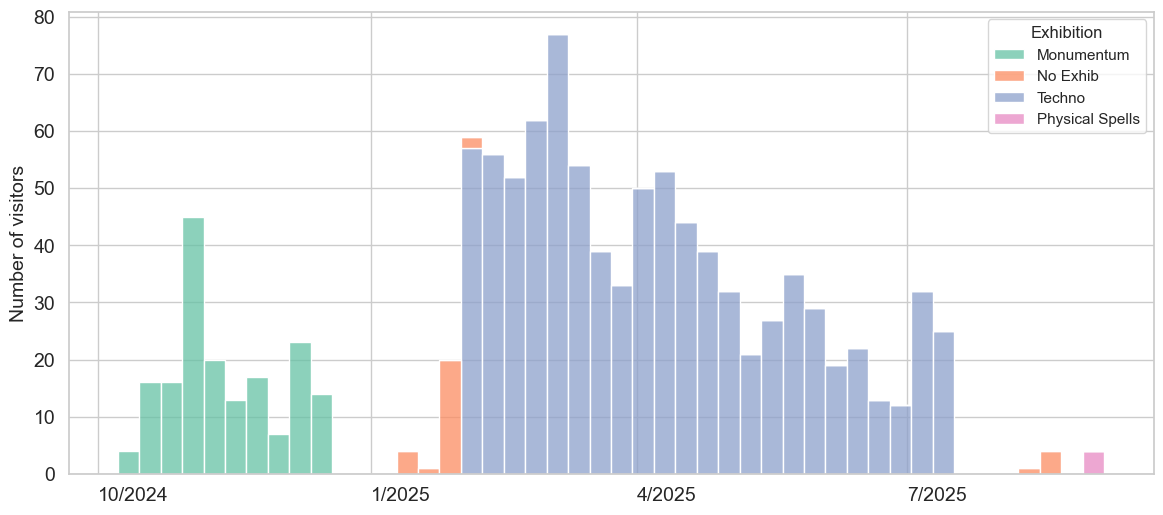

In [24]:
#x_dates = pd.date_range(start='2022-09-01', end='2024-07-01', freq='MS', inclusive='both')
x_dates = pd.date_range(start='2024-10-01', end='2025-09-09', freq='QS', inclusive='both')
#print(x_dates)

fig, ax = plt.subplots(figsize=(14,6))
fig = sns.histplot(data=df, x='DateTime', hue='Exhibition', weights="Quantity", bins=46, multiple='stack', 
                   palette="Set2",)
ax.set_xticks(x_dates, labels=x_dates.strftime('%-m/%Y'), horizontalalignment='left')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of visitors")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("311_timeline_scatter.png",bbox_inches='tight')
plt.show()

In [25]:
df['NumTime'] = [int(j.strftime('%-H%M')) for j in df['DateTime']]
# astype("int64")
print(df['NumTime'])

0      1613
1      1511
2      1518
3      1048
4      1354
       ... 
833    1157
834    1256
835    1442
836    1610
837    1643
Name: NumTime, Length: 838, dtype: int64


/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_73772/1869533144.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hour_labels)


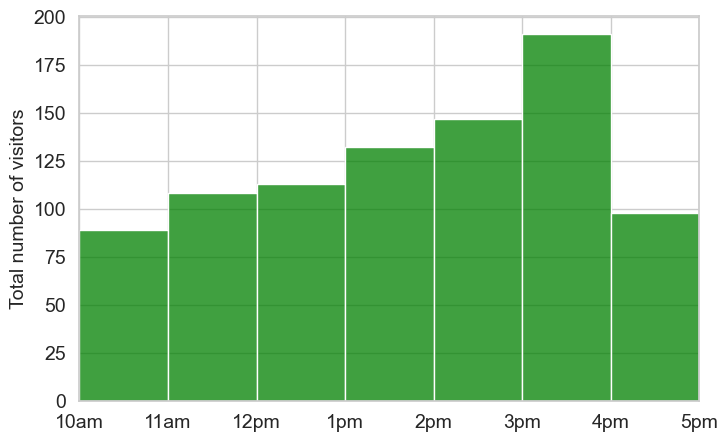

In [26]:
hours=(1000,1100,1200,1300,1400,1500,1600,1700)
hour_labels=("10am","11am","12pm","1pm","2pm","3pm","4pm","5pm")
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.histplot(data=df, x='NumTime', weights='Quantity', bins=hours, color='green')
ax.set_xlim(1000, 1700)
ax.set_xticklabels(hour_labels)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Total number of visitors")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("311_time_bar.png", bbox_inches='tight')
plt.show()

In [27]:
day_cats = ['Tue', 'Wed', 'Thu', 'Fri', 'Sat']
df['Day'] = pd.Categorical(df['Day'], categories=day_cats, ordered=True)

In [28]:
df.groupby('Day', observed=False, dropna=True)['Quantity'].sum()

Day
Tue    161
Wed    168
Thu    218
Fri    199
Sat    267
Name: Quantity, dtype: int64

/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_73772/3819884334.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels())


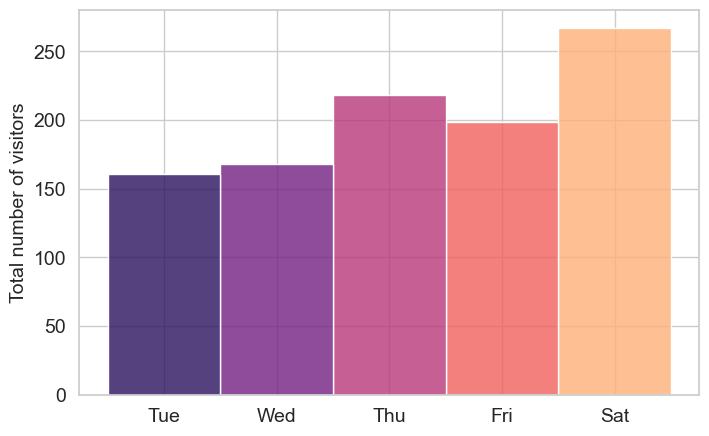

In [29]:
fig, ax = plt.subplots(figsize=(8,5))
fig = sns.histplot(df, x='Day', hue='Day', weights='Quantity', palette='magma', alpha=0.8, legend=False)
fig.set_xticklabels(fig.get_xticklabels())
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel("")
ax.set_ylabel("Total number of visitors")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("311_day_bar.png", bbox_inches='tight')
plt.show()

/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_73772/1853077338.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels(), rotation=345)
/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_73772/1853077338.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hour_labels)


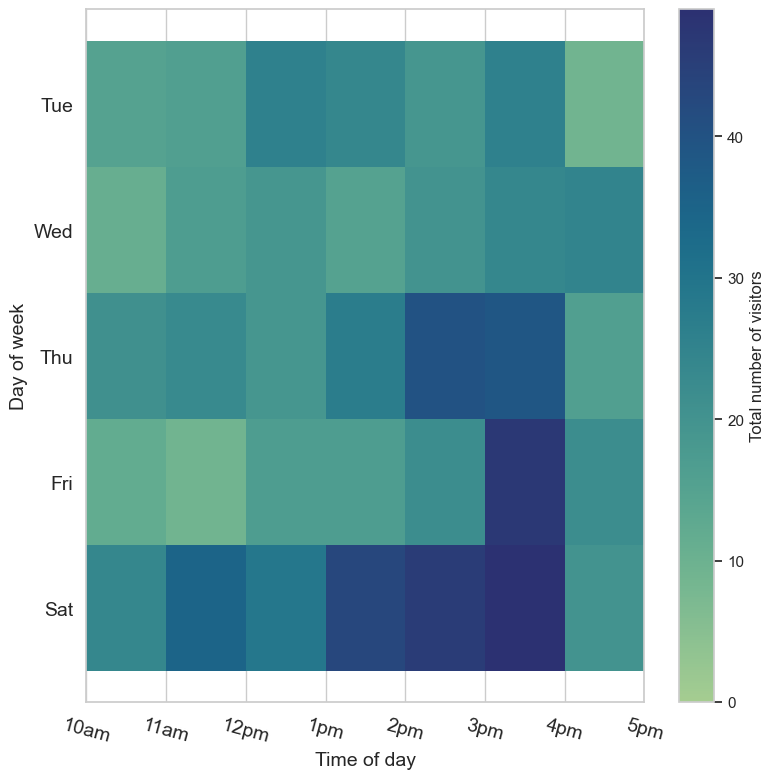

In [30]:
fig, ax = plt.subplots(figsize=(9,9))
fig = sns.histplot(df, x='NumTime', y='Day', weights='Quantity', bins=hours, 
                   cmap='crest', cbar=True, cbar_kws={'label':'Total number of visitors'})
fig.set_xticklabels(fig.get_xticklabels(), rotation=345)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlim(1000, 1700)
ax.set_xticklabels(hour_labels)
ax.set_xlabel("Time of day")
ax.set_ylabel("Day of week")
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
fig.figure.savefig("311_daytime_2D.png", bbox_inches='tight')
plt.show()